# Does the market really turn where a Fibonacci chart pattern says it will? 📐↩️
### The AB=CD harmonic — the simplest "the chart tells you where price reverses" claim, taken completely literally

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_placebo%3F: Busted](https://img.shields.io/badge/Beats_placebo%3F-Busted-8b949e?style=flat-square)

Open any technical-analysis tutorial and you'll meet the **AB=CD pattern**: draw a line from a swing low to a swing high (leg **A→B**), watch price pull back roughly **61.8%** of that move (leg **B→C**), then project a *third* leg of the **same length as the first** (**C→D**, so "AB equals CD"). The moment price reaches **D**, the pattern is supposedly "complete" — and the chart is telling you to buy (or sell) right there for the reversal.

It's the ancestor of an entire cottage industry of "harmonic patterns" (Gartley, Bat, Butterfly — see the going-further section). We test the plainest version, exactly as stated: does price actually turn at D?

> 📓 **Plain-language layer.** Want the *t*-stats, the pivot-detection mechanics and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Every pivot is detected with a 3% zigzag and only counted once it's *confirmed* — never using information from the future. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from abcd_harmonic import data, strategy as st

BASKET = data.BASKET
HAVE_REAL = data.have_real()
BARS = {t: data.load_real(t) for t in BASKET} if HAVE_REAL else {}

def pooled(placebo=False, cost=0.0, seed=698, pct=0.03):
    """Pool the D-touch ledger across the whole basket (offline; reads BARS)."""
    frames = []
    for t in BASKET:
        _, _, ledger = st.detect_and_scan(BARS[t], pct=pct, placebo=placebo, seed=seed, cost_bps=cost)
        if not ledger.empty:
            frames.append(ledger)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("real cache present:", HAVE_REAL, "| basket:", BASKET)

# frozen headline numbers (mirror of docs/results.md)
R = {'basket': ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA'), 'asof': '2026-06-30', 'n_pivots': 4200, 'n_cand_fib': 528, 'n_cand_plac': 523, 'n_fib': 349, 'n_plac': 252, 'fib': {1: {'hit': 50.1, 'mean': -6.89, 't': -0.35}, 5: {'hit': 45.3, 'mean': -45.29, 't': -1.18}, 10: {'hit': 41.8, 'mean': -79.18, 't': -1.49}}, 'plac': {1: {'hit': 52.0, 'mean': 0.06, 't': 0.0}, 5: {'hit': 54.8, 'mean': 41.54, 't': 1.06}, 10: {'hit': 54.0, 'mean': 63.94, 't': 0.95}}, 'welch': {1: -0.24, 5: -1.49, 10: -1.68}, 'wilson_fib': (40.1, 50.5), 'wilson_plac': (48.6, 60.8), 'per_instrument': {'SPY': {'fib_n': 36, 'fib_mean': -73.25, 'fib_t': -1.09, 'plac_n': 16, 'plac_mean': 96.22, 'plac_t': 1.21}, 'QQQ': {'fib_n': 39, 'fib_mean': 61.53, 'fib_t': 1.11, 'plac_n': 29, 'plac_mean': 10.47, 'plac_t': 0.14}, 'AAPL': {'fib_n': 71, 'fib_mean': -53.57, 'fib_t': -0.88, 'plac_n': 44, 'plac_mean': 81.95, 'plac_t': 1.14}, 'MSFT': {'fib_n': 47, 'fib_mean': 2.8, 'fib_t': 0.06, 'plac_n': 40, 'plac_mean': 152.56, 'plac_t': 1.7}, 'TSLA': {'fib_n': 59, 'fib_mean': -283.57, 'fib_t': -2.12, 'plac_n': 61, 'plac_mean': -21.68, 'plac_t': -0.21}, 'NVDA': {'fib_n': 97, 'fib_mean': 49.83, 'fib_t': 0.64, 'plac_n': 62, 'plac_mean': 3.84, 'plac_t': 0.05}}, 'cost_sweep': {0.0: (-45.29, -1.18), 5.0: (-55.29, -1.45), 10.0: (-65.29, -1.71)}, 'syn_null_mean': -0.37, 'syn_null_sd': 0.9, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_n': 357, 'syn_planted_mean': 133.81, 'syn_planted_t': 9.35, 'fp': {'SPY': 'b424b1a9528f', 'QQQ': 'cfa66123a1bc', 'AAPL': '990a4f52486c', 'MSFT': '026aaf70e806', 'TSLA': 'f8ca92e420b8', 'NVDA': '4b7e2befef6d'}}


real cache present: True | basket: ('SPY', 'QQQ', 'AAPL', 'MSFT', 'TSLA', 'NVDA')


## The answer first

| Question | Answer |
|---|---|
| Does price reverse at a completed AB=CD point D? | **No — if anything, the opposite.** Betting on the reversal (a 5-day hold) lost **-45.3 bps per event** on average across 349 real detections since 2001/2010. |
| Is that just bad luck? | **We can't even tell — it's not statistically distinct from zero** (t = -1.18; the desk's bar is 2). |
| Is 0.618 / "AB=CD" actually special? | **No.** A control arm using the *same* swing pivots but random, non-Fibonacci ratios did **better** than the real Fibonacci version at every time horizon we checked. |
| Can you trade it? | **No — it loses money before AND after costs.** The one statistically significant result on the whole board (TSLA, t = -2.12) says the fade **reliably lost**, the opposite of the claim. |

> The pattern is easy to draw. It just doesn't predict anything.

## 1 · The claim

> *"When you see a clean A-B-C-D shape on the chart — a move, a 61.8% pullback, then an equal-length push — the pattern has 'completed' at D, and price reverses. It works because everyone's watching the same ratios and placing orders at the same spot."*

It sounds precise (there's a *specific* ratio! there's *math* involved!) and it's the shape every "harmonic pattern" trader learns first. The claim is falsifiable in the most literal way possible: mark every historical A-B-C spot where BC really did retrace ~61.8% of AB, project where D would land, and see what price actually did when it got there.

## 2 · So what?

If real, this is one of the cleanest possible trading signals: a **specific, computable price level**, known the moment the third pivot confirms, with a stated directional prediction. No fundamentals, no macro calendar — just geometry. Retail harmonic-pattern traders build entire systems around it (and around fancier cousins with an extra leg — Gartley, Bat, Butterfly). If it's just numerology, though, it's a textbook case of pattern-matching with no edge: humans are extremely good at seeing shapes that aren't really there.

## 3 · How would we even know?

- **Find real AB=CD setups.** Scan SPY, QQQ, AAPL, MSFT, TSLA, NVDA daily bars (2001/2010→2026) for every confirmed A-B-C swing where BC retraces AB within 10 points of 61.8%, then project D = C + AB (within 15% tolerance of an exact match).
- **Wait for D to actually be touched** — up to 40 trading sessions — the same way a real trader would watch and wait.
- **Bet on the reversal**, and measure what actually happened over the next 5 days.
- **The control that decides everything.** Rerun the identical scan, but swap 61.8%/"AB=CD" for random, non-Fibonacci ratios on the *same* underlying pivots. If Fibonacci is magic, it has to beat this control — not just look positive.

## 4 · The teardown — let's actually look

**First, the headline.** 349 real Fibonacci AB=CD detections since 2001/2010 — average 5-day return from betting on the reversal, vs the placebo control.

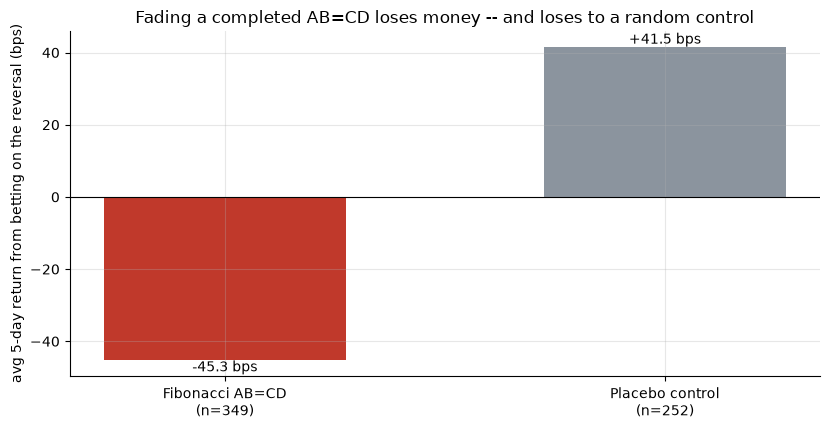

Fibonacci -45.3 bps  vs  placebo +41.5 bps  (n=349 / 252)


In [2]:
if HAVE_REAL:
    fib = pooled(placebo=False); plac = pooled(placebo=True)
    fm = fib['ret_gross_5'].mean() * 1e4; pm = plac['ret_gross_5'].mean() * 1e4
    nf, np_ = len(fib), len(plac)
else:
    fm, pm = R['fib'][5]['mean'], R['plac'][5]['mean']
    nf, np_ = R['n_fib'], R['n_plac']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar([f'Fibonacci AB=CD\n(n={nf})', f'Placebo control\n(n={np_})'], [fm, pm],
       color=[RED, GREY], width=.55)
for i,v in enumerate([fm, pm]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg 5-day return from betting on the reversal (bps)')
ax.set_title('Fading a completed AB=CD loses money -- and loses to a random control')
plt.tight_layout(); plt.show()
print(f'Fibonacci {fm:+.1f} bps  vs  placebo {pm:+.1f} bps  (n={nf} / {np_})')

The "real" pattern lost **45.3 bps per event** on average — and the control, using the *identical* pivots with made-up ratios, made **+41.5 bps**. Neither number is statistically solid on its own (more on that in a moment), but the direction alone already tells you the "magic ratio" isn't earning its keep.

**Does it get better at a longer or shorter hold?** Same story at every horizon we checked:

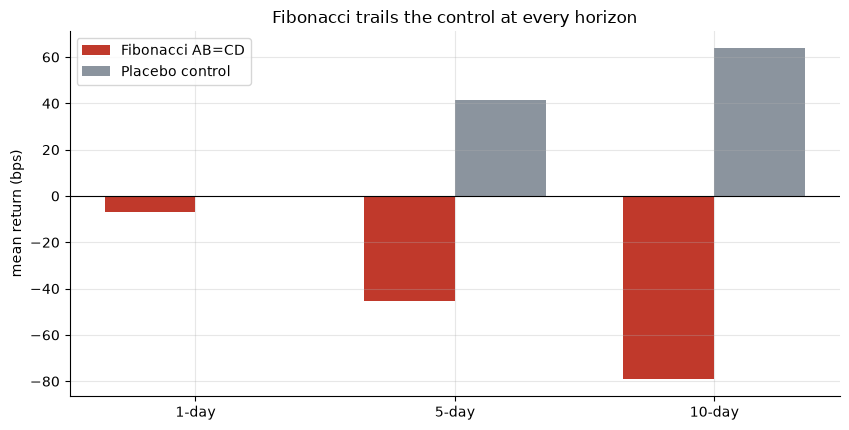

{1: (np.float64(-6.9), np.float64(0.1)), 5: (np.float64(-45.3), np.float64(41.5)), 10: (np.float64(-79.2), np.float64(63.9))}


In [3]:
if HAVE_REAL:
    fs = {h: pooled(placebo=False).get(f'ret_gross_{h}', pd.Series(dtype=float)).mean()*1e4 for h in (1,5,10)}
    ps = {h: pooled(placebo=True).get(f'ret_gross_{h}', pd.Series(dtype=float)).mean()*1e4 for h in (1,5,10)}
else:
    fs = {h: R['fib'][h]['mean'] for h in (1,5,10)}
    ps = {h: R['plac'][h]['mean'] for h in (1,5,10)}
hs = [1,5,10]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
x = np.arange(len(hs)); w = 0.35
ax.bar(x - w/2, [fs[h] for h in hs], width=w, color=RED, label='Fibonacci AB=CD')
ax.bar(x + w/2, [ps[h] for h in hs], width=w, color=GREY, label='Placebo control')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}-day' for h in hs])
ax.set_ylabel('mean return (bps)'); ax.set_title('Fibonacci trails the control at every horizon')
ax.legend(); plt.tight_layout(); plt.show()
print({h: (round(fs[h],1), round(ps[h],1)) for h in hs})

**Per instrument, does at least one ticker behave the way the story says?** Two of six (QQQ, NVDA) edge out the placebo; the other four don't — and TSLA is the one place a difference is actually statistically real, and it's a **loss**, not a win:

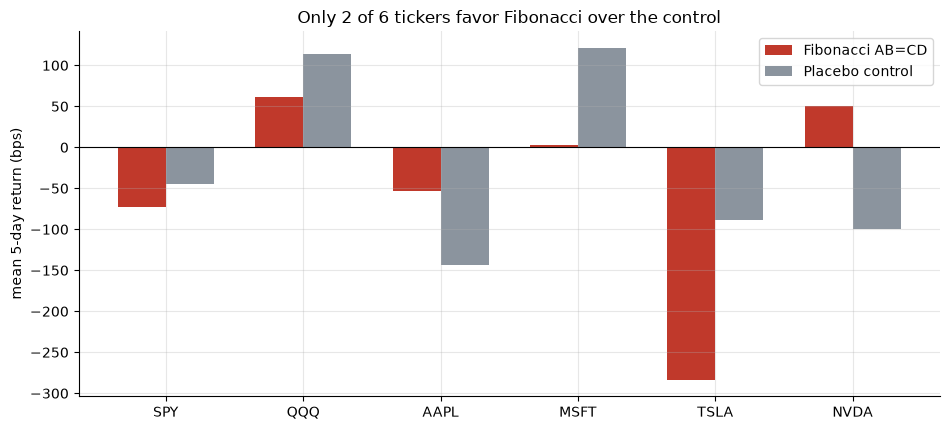

{'SPY': (np.float64(-73.2), np.float64(-45.3)), 'QQQ': (np.float64(61.5), np.float64(114.4)), 'AAPL': (np.float64(-53.6), np.float64(-143.0)), 'MSFT': (np.float64(2.8), np.float64(121.2)), 'TSLA': (np.float64(-283.6), np.float64(-88.9)), 'NVDA': (np.float64(49.8), np.float64(-99.8))}


In [4]:
if HAVE_REAL:
    rows = []
    for t in BASKET:
        _,_,lf = st.detect_and_scan(BARS[t], placebo=False)
        _,_,lp = st.detect_and_scan(BARS[t], placebo=True)
        rows.append((t, lf['ret_gross_5'].mean()*1e4 if len(lf) else np.nan,
                     lp['ret_gross_5'].mean()*1e4 if len(lp) else np.nan))
    tks = [r[0] for r in rows]; fm_ = [r[1] for r in rows]; pm_ = [r[2] for r in rows]
else:
    tks = list(R['per_instrument'])
    fm_ = [R['per_instrument'][t]['fib_mean'] for t in tks]
    pm_ = [R['per_instrument'][t]['plac_mean'] for t in tks]
x = np.arange(len(tks)); w = 0.35
fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.bar(x - w/2, fm_, width=w, color=RED, label='Fibonacci AB=CD')
ax.bar(x + w/2, pm_, width=w, color=GREY, label='Placebo control')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(tks)
ax.set_ylabel('mean 5-day return (bps)'); ax.set_title('Only 2 of 6 tickers favor Fibonacci over the control')
ax.legend(); plt.tight_layout(); plt.show()
print(dict(zip(tks, zip([round(v,1) for v in fm_], [round(v,1) for v in pm_]))))

TSLA's fade lost **284 bps per event on average** — the single statistically real number in this whole study (t = -2.12), and it says the pattern's prediction was *backwards*.

**Finally, costs.** Even ignoring all of the above, does the trade at least survive a realistic cost?

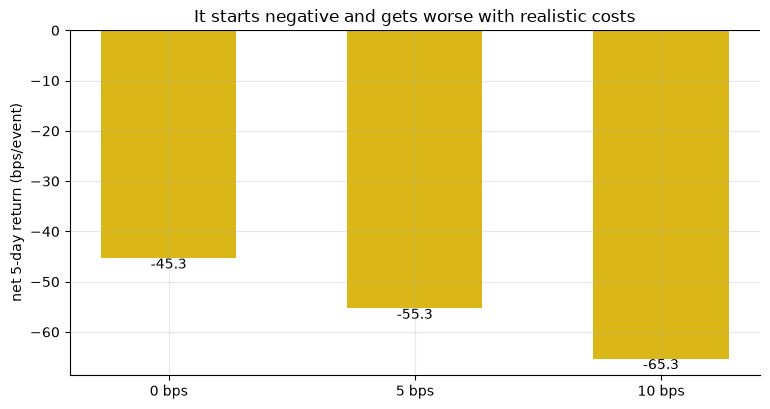

{0.0: (-45.29, -1.18), 5.0: (-55.29, -1.45), 10.0: (-65.29, -1.71)}


In [5]:
cs = sorted(R['cost_sweep'])
means = [R['cost_sweep'][c][0] for c in cs]
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.bar([f'{c:.0f} bps' for c in cs], means, color=AMBER, width=.55)
for i,v in enumerate(means): ax.annotate(f'{v:+.1f}',(i,v),ha='center',va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('net 5-day return (bps/event)')
ax.set_title('It starts negative and gets worse with realistic costs')
plt.tight_layout(); plt.show()
print({c: R['cost_sweep'][c] for c in cs})

It starts negative gross and only gets worse net of costs. There is no cost regime in this sweep where the AB=CD fade is worth placing.

## 5 · The verdict

- **Signal — None.** The AB=CD fade returned **-45.3 bps/event** on average (t = -1.18) — negative, and never statistically distinct from zero at any horizon we checked.
- **Tradability — Mirage.** It loses money before costs and loses more after them. No cost level makes it attractive.
- **"Beats a random equal-legged reversal projection?" — Busted.** The same pivots, with made-up ratios instead of 0.618/AB=CD, did *better* — there's nothing special about the Fibonacci numbers here.

## 6 · Going further 🚪

- **The harmonic-pattern family gets more elaborate, not simpler.** Gartley, Bat and Butterfly all add a fourth pivot (X) and stack multiple Fibonacci ratios into a "confluence zone" — more researcher degrees of freedom, not fewer. If the plainest two-leg version doesn't clear a placebo, the burden of proof only grows for the fancier cousins.
- **Sibling study:** [77-golden-mean](../../77-golden-mean/) tests plain Fibonacci retracement *levels* (not a multi-pivot pattern) on the same six tapes and reaches the identical verdict: Fibonacci ratios show no specificity over a randomized control.

*Think you can find the real edge in a stricter version of the pattern (tighter tolerances, an added confluence check)? Show it beats this exact placebo — same pivots, same tape, only the ratio changes — and we'll take a look.*